# Spectral fitting example (AGN)

**To run this, you need the following files, which can be downloaded using the first few cells of this notebook:**
- orientation file (20280301_3_month_with_orbital_info.ori)       
- binned data (NGC4151_faint_bkg_binned_data.hdf5, NGC4151_faint_binned_data.hdf5, & bkg_binned_data.hdf5)     
- detector response (SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.nonsparse_nside8.area.good_chunks_unzip.h5.zip)     

**The binned data are simulations of the NGC4151_faint Nebula and albedo photon background produced using the COSI SMEX mass model. The detector response needs to be unzipped before running the notebook.**

This notebook fits the spectrum of a NGC4151_faint simulated using MEGAlib and combined with background.

[3ML](https://threeml.readthedocs.io/) is a high-level interface that allows multiple datasets from different instruments to be used coherently to fit the parameters of source model. A source model typically consists of a list of sources with parametrized spectral shapes, sky locations and, for extended sources, shape. Polarization is also possible. A "coherent" analysis, in this context, means that the source model parameters are fitted using all available datasets simultanously, rather than performing individual fits and finding a well-suited common model a posteriori. 

In order for a dataset to be included in 3ML, each instrument needs to provide a "plugin". Each plugin is responsible for reading the data, convolving the source model (provided by 3ML) with the instrument response, and returning a likelihood. In our case, we'll compute a binned Poisson likelihood:

$$
\log \mathcal{L}(\mathbf{x}) = \sum_i \log \frac{\lambda_i(\mathbf{x})^{d_i} \exp (-\lambda_i)}{d_i!}
$$

where $d_i$ are the counts on each bin and $\lambda_i$ are the expected counts given a source model with parameters $\mathbf{x}$. 

In this example, we will fit a single point source with a known location. We'll assume the background is known and fixed up to a scaling factor. Finally, we will fit a Band function:

$$
f(x) = K \begin{cases} \left(\frac{x}{E_{piv}}\right)^{\alpha} \exp \left(-\frac{(2+\alpha)
       * x}{x_{p}}\right) & x \leq (\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \\ \left(\frac{x}{E_{piv}}\right)^{\beta}
       * \exp (\beta-\alpha)\left[\frac{(\alpha-\beta) x_{p}}{E_{piv}(2+\alpha)}\right]^{\alpha-\beta}
       * &x>(\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \end{cases}
$$

where $K$ (normalization), $\alpha$ & $\beta$ (spectral indeces), and $x_p$ (peak energy) are the free parameters, while $E_{piv}$ is the pivot energy which is fixed (and arbitrary).

Considering these assumptions:

$$
\lambda_i(\mathbf{x}) = B*b_i + s_i(\mathbf{x})
$$

where $B*b_i$ are the estimated counts due to background in each bin with $B$ the amplitude and $b_i$ the shape of the background, and $s_i$ are the corresponding expected counts from the source, the goal is then to find the values of $\mathbf{x} = [K, \alpha, \beta, x_p]$ and $B$ that maximize $\mathcal{L}$. These are the best estimations of the parameters.

The final module needs to also fit the time-dependent background, handle multiple point-like and extended sources, as well as all the spectral models supported by 3ML. Eventually, it will also fit the polarization angle. However, this simple example already contains all the necessary pieces to do a fit.

In [1]:
from cosipy import COSILike, test_data, BinnedData
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

from scoords import SpacecraftFrame

from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt

from threeML import *
from threeML.io.package_data import get_path_of_data_file
from threeML.io.logging import silence_console_log
from astromodels import Parameter

from jupyterthemes import jtplot
jtplot.style(context="talk", fscale=1, ticks=True, grid=False)
set_threeML_style()
silence_warnings()


from pathlib import Path

import os


%matplotlib inline

15:24:19 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=275915;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=653561;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#45\45]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=158414;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=120151;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#67\67]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=299898;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=498154;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#34\34]8;;\
                  available                                                                                        

15:24:20 INFO      Starting 3ML!                                                                     ]8;id=294453;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=624899;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py#39\39]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=210482;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=685860;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py#40\40]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=29193;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=30757;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=956095;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=84647;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=581693;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=811168;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=655683;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=567674;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=216135;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=773696;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

## Download and read in binned data

Define the path to the directory containing the data, detector response, orientation file, and yaml files if they have already been downloaded, or the directory to download the files into

In [6]:
data_path = Path("/Users/parshadkp/Software/COSI_Data/")

Read in the spacecraft orientation file

In [4]:
sc_orientation = SpacecraftFile.parse_from_file(data_path / "DC3_Files/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori") #DC3

In [5]:
dr = str(data_path / "DC3_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse_nside8.area.good_chunks.h5") # DC3

# COSI Analysis

In [81]:
NGC4151_faint = BinnedData('/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/NGC4151_ec200.yaml')
NGC4151_faint_bkg = BinnedData('/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/NGC4151_ec200.yaml')
bkg = BinnedData('/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/background.yaml')

Load binned .hdf5 files

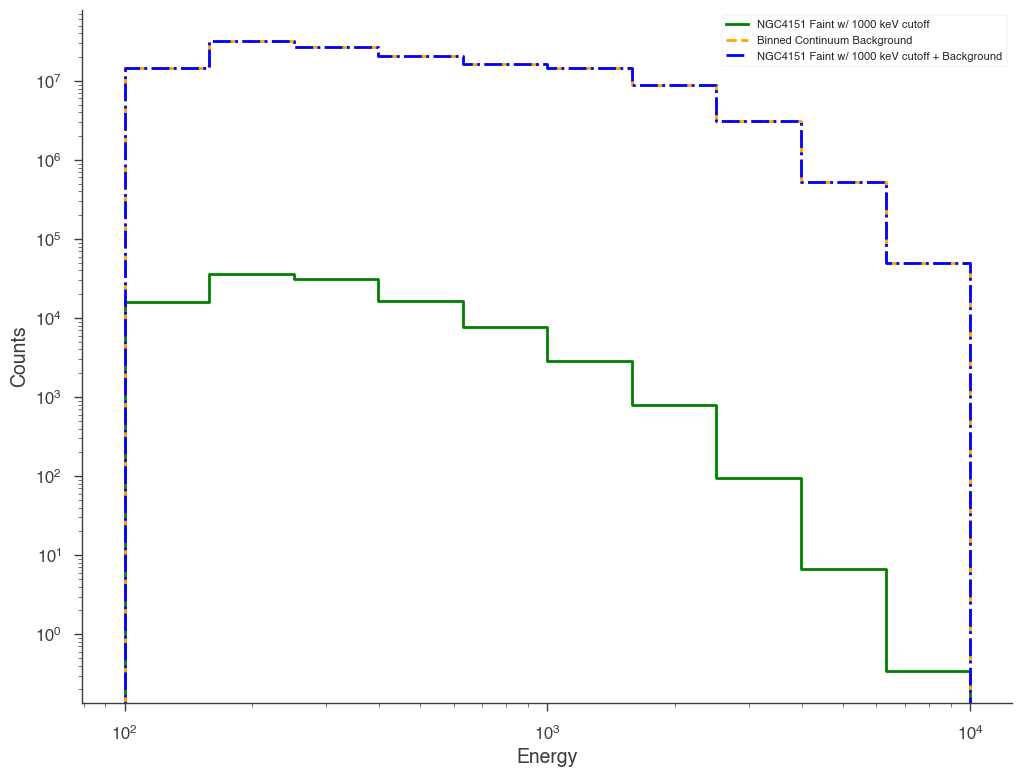

In [ ]:
multiplier = 5.0

NGC4151_faint = Histogram.open(data_path/"AGN_Data/GammaRay/DC3/NGC_4151_ec1000_faint_DC3_COSI.hdf5")*multiplier
bkg = Histogram.open(data_path /  "AGN_Data/GammaRay/DC3/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut_NGC4151_TimeCut.hdf5")*multiplier
NGC4151_faint_bkg = Histogram.open(data_path / "AGN_Data/GammaRay/DC3/NGC_4151_ec1000_faint_DC3_COSI_TimeCutBkg.hdf5")*multiplier

fig, ax = plt.subplots(figsize=(12, 9))
NGC4151_faint.project("Em").draw(ax, label="NGC4151 Faint w/ 1000 keV cutoff", color="green")
bkg.project("Em").draw(ax, label="Binned Continuum Background", color="orange", linestyle="dashed")
NGC4151_faint_bkg.project("Em").draw(ax, label="NGC4151 Faint w/ 1000 keV cutoff + Background", linestyle='dashdot', color="blue")

ax.set_yscale("log")
ax.set_xscale("log")

# ax.set_ylim(1e0, 1e8)
ax.set_ylabel("Counts")
ax.set_xlabel("Energy")
plt.legend()

Define the path to the detector response

## Perform spectral fit

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [59]:
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_faint_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = False)                                             # Option to account for Earth occultation

Define a point source at the known location with a Band function spectrum and add it to the model. The initial values of the Band function parameters are set to the true values used to simulate the source

### Powerlaw with energy cutoff fit

In [60]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 0.1 / u.cm / u.cm / u.s / u.keV
piv = 1. * u.keV
xc = 100. * u.keV
index = -2.5

spectrum = Cutoff_powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.xc.value = xc.value
spectrum.index.value = index

# Harsher Parameters
spectrum.K.min_value = 1e-4
spectrum.K.max_value = 2
spectrum.xc.min_value = 1 # keep these relatively the same
spectrum.xc.max_value = 10000 # change to 1000
spectrum.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum.index.max_value = 1

spectrum.K.delta = 0.05
spectrum.xc.delta = 10
spectrum.index.delta = 0.25

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit
spectrum.xc.unit = xc.unit

source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# # Optional: free the position parameters
# #source.position.l.free = True
# #source.position.b.free = True

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
cosi.set_model(model)

Gather all plugins and combine with the model in a JointLikelihood object, then perform maximum likelihood fit

In [61]:
# bat.use_effective_area_correction(0.2, 2.5)
# plugins = DataList(bat, cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)
# nustar_fpma.use_effective_area_correction(0.2, 1.8)
# nustar_fpmb.use_effective_area_correction(0.2, 1.8)
# plugins = DataList(cosi, nustar_fpma, nustar_fpmb)
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit() #increase number of samples?

16:41:41 INFO      set the minimizer to minuit                                             ]8;id=785500;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=475040;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
source.spectrum.main.Cutoff_powerlaw.K,(2.0 -1.1 +2.2) x 10^-1,1 / (keV s cm2)
source.spectrum.main.Cutoff_powerlaw.index,-1.96 +/- 0.15,
source.spectrum.main.Cutoff_powerlaw.xc,(1.2 -0.5 +0.8) x 10^3,keV
background_cosi,(9.9997 +/- 0.0011) x 10^-1,


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-8.298594e+08
total,-8.298594e+08


Values of statistical measures:

,statistical measures
AIC,-1.659719e+09
BIC,-1.659719e+09


(                                                  value  negative_error  \
 source.spectrum.main.Cutoff_powerlaw.K         0.197954       -0.108897   
 source.spectrum.main.Cutoff_powerlaw.index    -1.961116       -0.153484   
 source.spectrum.main.Cutoff_powerlaw.xc     1169.080966     -478.145636   
 background_cosi                                0.999966       -0.000112   
 
                                             positive_error       error  \
 source.spectrum.main.Cutoff_powerlaw.K            0.225285    0.167091   
 source.spectrum.main.Cutoff_powerlaw.index        0.159156    0.156320   
 source.spectrum.main.Cutoff_powerlaw.xc         795.835808  636.990722   
 background_cosi                                   0.000115    0.000113   
 
                                                        unit  
 source.spectrum.main.Cutoff_powerlaw.K      1 / (keV s cm2)  
 source.spectrum.main.Cutoff_powerlaw.index                   
 source.spectrum.main.Cutoff_powerlaw.xc            

## Error propagation and plotting (Cutoff powerlaw function)

Define Band function spectrum injected into MEGAlib

In [64]:
K_inj = 0.035*multiplier / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.81

spectrum_inj = Cutoff_powerlaw()

spectrum_inj.K.value = K_inj.value
spectrum_inj.piv.value = piv_inj.value
spectrum_inj.xc.value = xc_inj.value
spectrum_inj.index.value = index_inj

spectrum_inj.K.unit = K_inj.unit
spectrum_inj.piv.unit = piv_inj.unit
spectrum_inj.xc.unit = xc_inj.unit

The summary of the results above tell you the optimal values of the parameters, as well as the errors. Propogate the errors to the "evaluate_at" method of the spectrum

In [65]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Cutoff_powerlaw.K,(2.0 -1.1 +2.2) x 10^-1,1 / (keV s cm2)
source.spectrum.main.Cutoff_powerlaw.index,-1.96 +/- 0.15,
source.spectrum.main.Cutoff_powerlaw.xc,(1.2 -0.5 +0.8) x 10^3,keV
background_cosi,(9.9997 +/- 0.0011) x 10^-1,


Correlation matrix:

1.00,-0.99,0.60,-0.06
-0.99,1.00,-0.69,0.03
0.60,-0.69,1.00,-0.23
-0.06,0.03,-0.23,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-8.298594e+08
total,-8.298594e+08


Values of statistical measures:

,statistical measures
AIC,-1.659719e+09
BIC,-1.659719e+09


None
  * source (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Cutoff_powerlaw:
          * K:
            * value: 0.19795368412911468
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 0.0001
            * max_value: 2.0
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 1.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: -1.9611164490319162
   

Evaluate the flux and errors at a range of energies for the fitted and injected spectra, and the simulated source flux

In [66]:
energy = np.geomspace(200*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)
    
binned_energy_edges = NGC4151_faint.axes['Em'].edges.value
# print(binned_energy_edges)
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source']

Plot the fitted and injected spectra

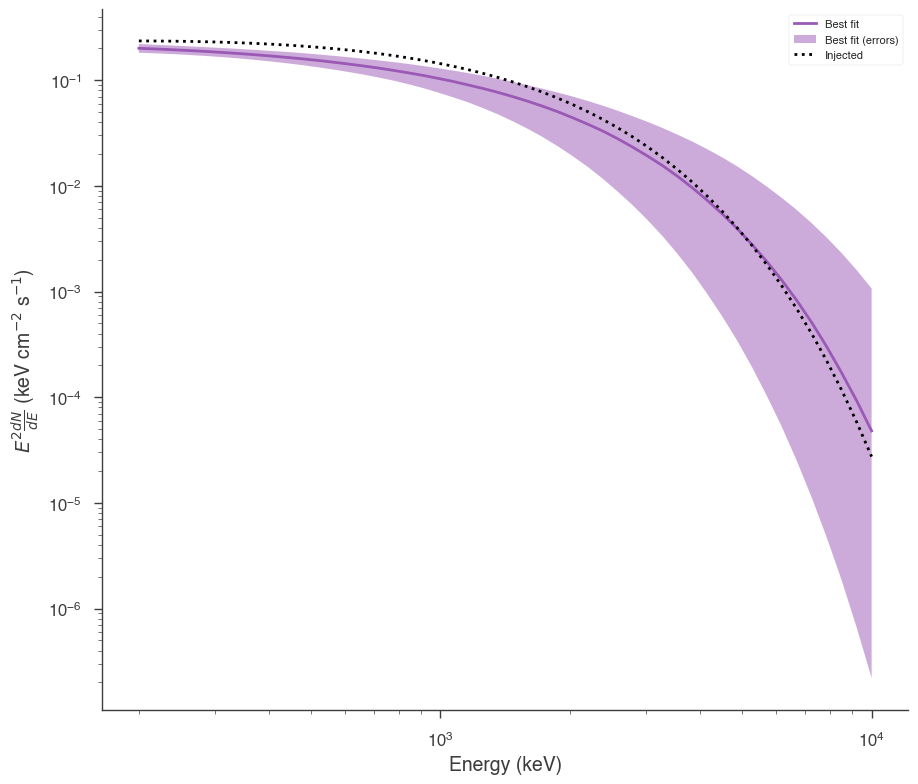

In [67]:
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

# ax.set_ylim(1e-5, 1)

ax.legend()

Plot the fitted spectrum convolved with the response, as well as the simulated source counts

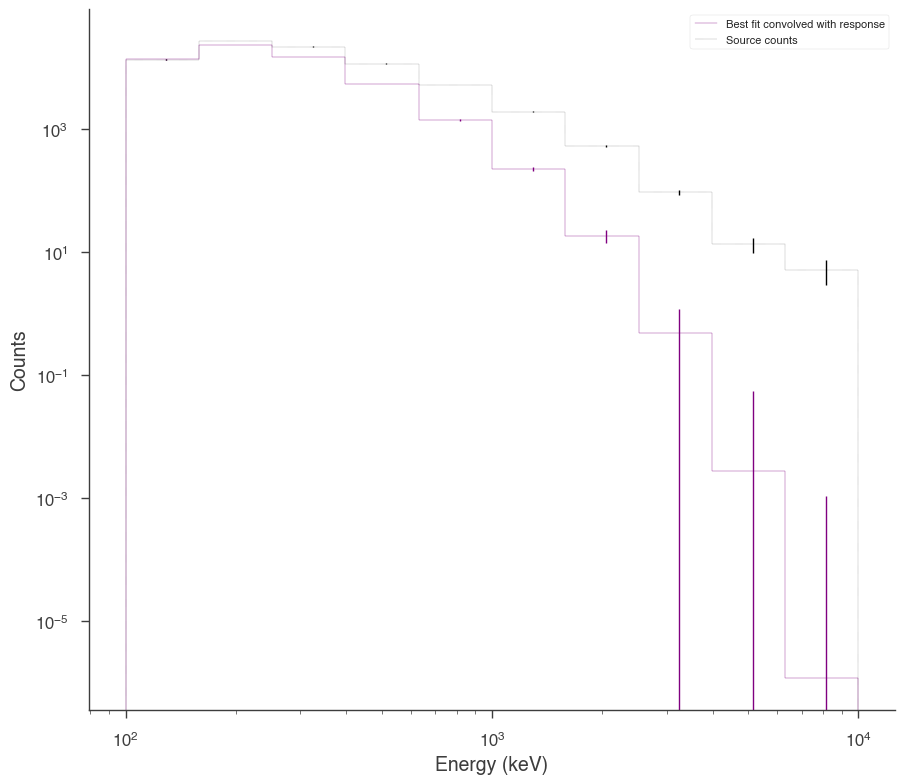

In [92]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(NGC4151_faint.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, NGC4151_faint.project('Em').todense().contents, yerr=np.sqrt(NGC4151_faint.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

Plot the fitted spectrum convolved with the response plus the fitted background, as well as the simulated source+background counts

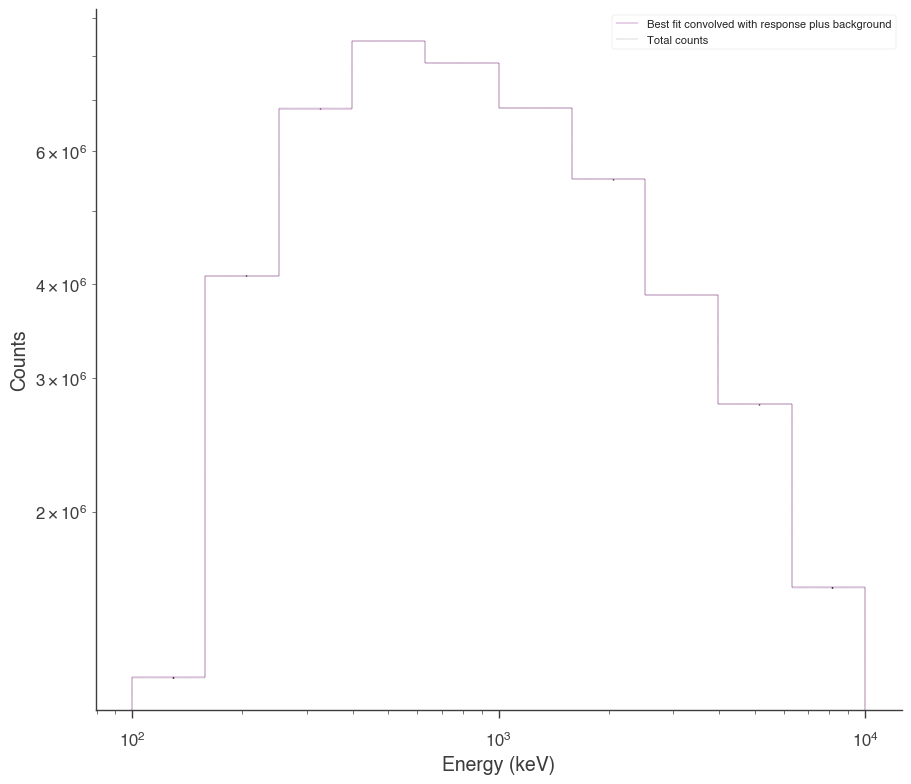

In [93]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents), binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents), yerr=np.sqrt(expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents)), color='purple', linewidth=0, elinewidth=1)
ax.stairs(NGC4151_faint_bkg.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, NGC4151_faint_bkg.project('Em').todense().contents, yerr=np.sqrt(NGC4151_faint_bkg.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

# Bright NGC 4151 with 264 keV cutoff.

In [63]:
NGC4151_bright = BinnedData("/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/NGC4151_ec1000.yaml")
NGC4151_bright_bkg = BinnedData("/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/NGC4151_ec1000.yaml")
bkg = BinnedData("/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/background.yaml")

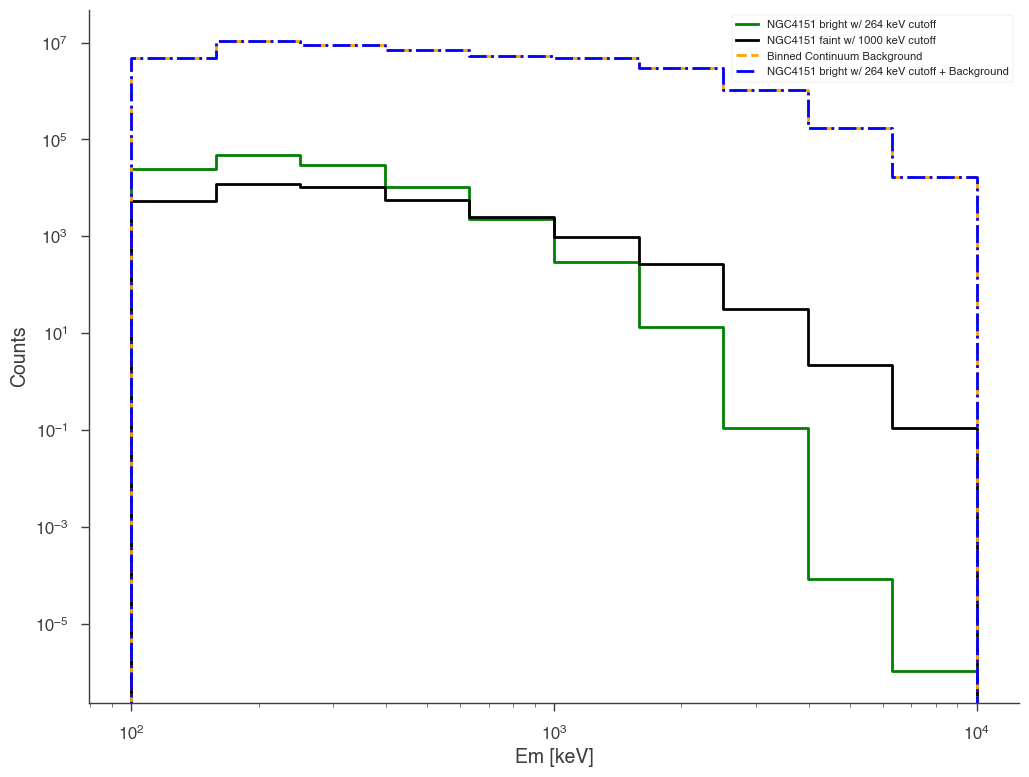

In [81]:
multiplier = 1.0

NGC4151_bright = Histogram.open(data_path/"AGN_Data/GammaRay/DC3/NGC_4151_ec264_bright_DC3_COSI.hdf5")*multiplier
bkg = Histogram.open(data_path /  "AGN_Data/GammaRay/DC3/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut_NGC4151_TimeCut.hdf5")*multiplier
NGC4151_bright_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/DC3/NGC_4151_ec264_bright_DC3_COSI_TimeCutBkg.hdf5")*multiplier
NGC4151_faint = Histogram.open(data_path/"AGN_Data/GammaRay/DC3/NGC_4151_ec1000_faint_DC3_COSI.hdf5")*multiplier

fig, ax = plt.subplots(figsize=(12, 9))
NGC4151_bright.project("Em").draw(ax, label="NGC4151 bright w/ 264 keV cutoff", color="green")
NGC4151_faint.project("Em").draw(ax, label="NGC4151 faint w/ 1000 keV cutoff", color="black")
bkg.project("Em").draw(ax, label="Binned Continuum Background", color="orange", linestyle="dashed")
NGC4151_bright_bkg.project("Em").draw(ax, label="NGC4151 bright w/ 264 keV cutoff + Background", linestyle='dashdot', color="blue")

ax.set_yscale("log")
ax.set_xscale("log")

# ax.set_ylim(1e0, 1e8)
ax.set_ylabel("Counts")
plt.legend()

In [82]:
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_bright_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

In [83]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 0.1 / u.cm / u.cm / u.s / u.keV
piv = 1. * u.keV
xc = 100. * u.keV
index = -1.75

spectrum = Cutoff_powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.xc.value = xc.value
spectrum.index.value = index

# #Working parameters
# spectrum.K.fix = True
# spectrum.index.fix = True

# Harsher Parameters
spectrum.K.min_value = 1e-4
spectrum.K.max_value = 1
spectrum.xc.min_value = 100 # keep these relatively the same
spectrum.xc.max_value = 10000 # change to 1000
spectrum.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum.index.max_value = 1

spectrum.K.delta = 0.05
spectrum.xc.delta = 10
spectrum.index.delta = 0.15

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit
spectrum.xc.unit = xc.unit

# fig, ax = plt.subplots()

# energy_grid = np.logspace(2, 4, 10000000)

# # ax.loglog(energy_grid, (energy_grid**2)*(spectrum(energy_grid)))
# ax.loglog(energy_grid, spectrum(energy_grid))
# ax.set_xlabel("energy [keV]")
# ax.set_ylim(1e-17, 1e-3)
# ax.set_ylabel(f"flux [{K.unit}]")

source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# # Optional: free the position parameters
# #source.position.l.free = True
# #source.position.b.free = True

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
cosi.set_model(model)

In [84]:
# bat.use_effective_area_correction(0.2, 2.5)
# plugins = DataList(bat, cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit() #increase number of samples?

16:52:44 INFO      set the minimizer to minuit                                             ]8;id=345921;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=510679;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
source.spectrum.main.Cutoff_powerlaw.K,(2.6 -0.8 +1.1) x 10^-1,1 / (keV s cm2)
source.spectrum.main.Cutoff_powerlaw.index,-1.85 +/- 0.08,
source.spectrum.main.Cutoff_powerlaw.xc,(3.1 +/- 0.5) x 10^2,keV
background_cosi,(9.9998 +/- 0.0019) x 10^-1,


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-2.269628e+08
total,-2.269628e+08


Values of statistical measures:

,statistical measures
AIC,-4.539255e+08
BIC,-4.539255e+08


(                                                 value  negative_error  \
 source.spectrum.main.Cutoff_powerlaw.K        0.257866       -0.080088   
 source.spectrum.main.Cutoff_powerlaw.index   -1.854971       -0.083545   
 source.spectrum.main.Cutoff_powerlaw.xc     309.079010      -46.864096   
 background_cosi                               0.999982       -0.000184   
 
                                             positive_error      error  \
 source.spectrum.main.Cutoff_powerlaw.K            0.116054   0.098071   
 source.spectrum.main.Cutoff_powerlaw.index        0.085068   0.084307   
 source.spectrum.main.Cutoff_powerlaw.xc          55.232553  51.048324   
 background_cosi                                   0.000181   0.000182   
 
                                                        unit  
 source.spectrum.main.Cutoff_powerlaw.K      1 / (keV s cm2)  
 source.spectrum.main.Cutoff_powerlaw.index                   
 source.spectrum.main.Cutoff_powerlaw.xc                 keV  

In [85]:
K_inj = 0.15*multiplier / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 264. * u.keV
index_inj = -1.71

spectrum_inj = Cutoff_powerlaw()

spectrum_inj.K.value = K_inj.value
spectrum_inj.piv.value = piv_inj.value
spectrum_inj.xc.value = xc_inj.value
spectrum_inj.index.value = index_inj

spectrum_inj.K.unit = K_inj.unit
spectrum_inj.piv.unit = piv_inj.unit
spectrum_inj.xc.unit = xc_inj.unit

In [86]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Cutoff_powerlaw.K,(2.6 -0.8 +1.1) x 10^-1,1 / (keV s cm2)
source.spectrum.main.Cutoff_powerlaw.index,-1.85 +/- 0.08,
source.spectrum.main.Cutoff_powerlaw.xc,(3.1 +/- 0.5) x 10^2,keV
background_cosi,(9.9998 +/- 0.0019) x 10^-1,


Correlation matrix:

1.00,-0.97,0.60,-0.08
-0.97,1.00,-0.75,0.08
0.60,-0.75,1.00,-0.24
-0.08,0.08,-0.24,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-2.269628e+08
total,-2.269628e+08


Values of statistical measures:

,statistical measures
AIC,-4.539255e+08
BIC,-4.539255e+08


None
  * source (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Cutoff_powerlaw:
          * K:
            * value: 0.25786603083980725
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 0.0001
            * max_value: 1.0
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 1.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: -1.8549705539020256
   

In [87]:
energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)
    
binned_energy_edges = NGC4151_faint.axes['Em'].edges.value
# print(binned_energy_edges)
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source']

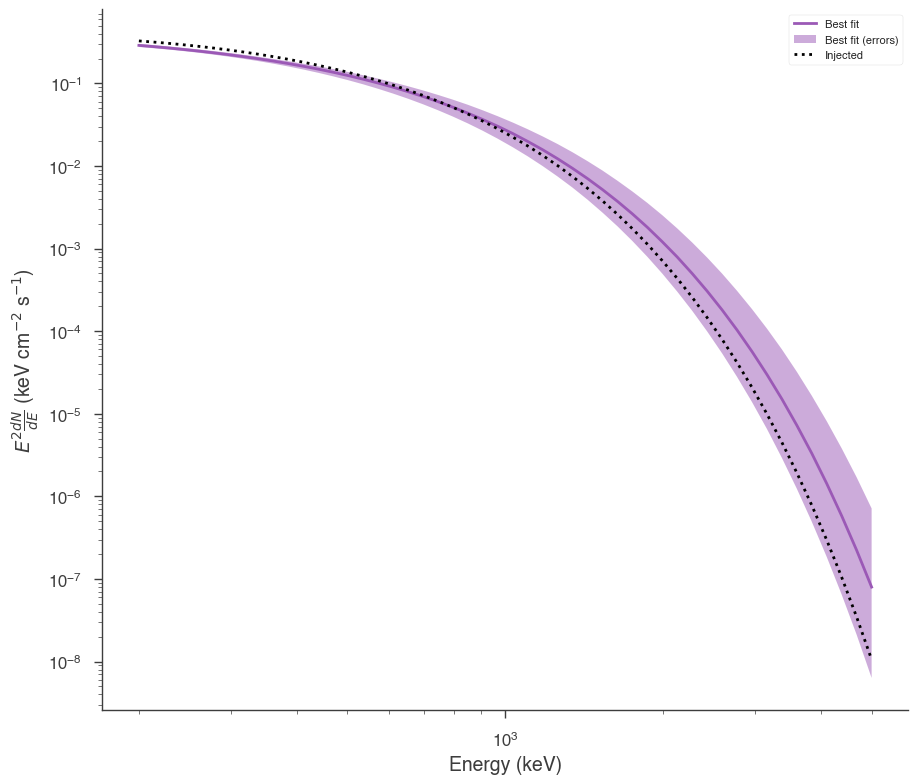

In [88]:
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

ax.legend()

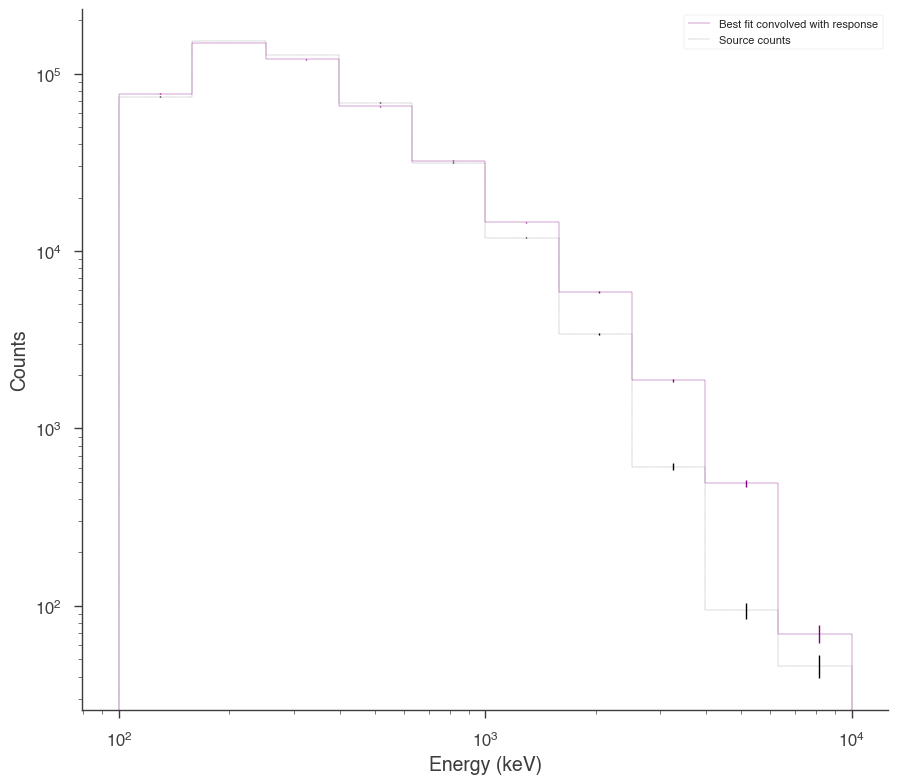

In [ ]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(NGC4151_bright.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, NGC4151_bright.project('Em').todense().contents, yerr=np.sqrt(NGC4151_bright.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

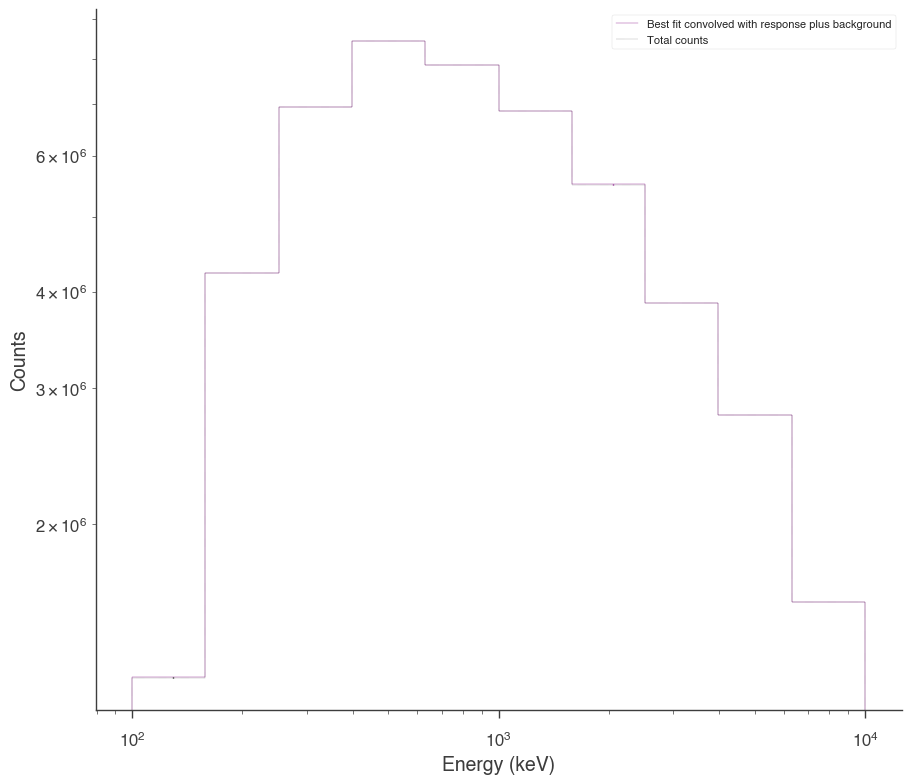

In [37]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents), binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents), yerr=np.sqrt(expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents)), color='purple', linewidth=0, elinewidth=1)
ax.stairs(NGC4151_bright_bkg.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, NGC4151_bright_bkg.project('Em').todense().contents, yerr=np.sqrt(NGC4151_bright_bkg.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()